In [3]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def delta(S, T, r, K, sigma, option_type:str='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    if option_type == 'call':
        return norm.cdf(d1)
    elif option_type == 'put':
        return norm.cdf(d1)-1

def gamma(S, T, r, K, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    return norm.pdf(d1)/(S*sigma*np.sqrt(T))

def vega(S, T, r, K, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    return S*norm.pdf(d1)*np.sqrt(T)

def theta(S, T, r, K, sigma, option_type:str='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return -r*K*norm.cdf(d2)*np.exp(-r*T) - (sigma*S*norm.pdf(d1))/(2*np.sqrt(T))
    elif option_type == 'put':
        return r*K*norm.cdf(-d2)*np.exp(-r*T) - (sigma*S*norm.pdf(d1))/(2*np.sqrt(T))

def rho(S, T, r, K, sigma, option_type:str='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return K*T*np.exp(-r*T)*norm.cdf(d2)
    elif option_type == 'put':
        return -K*T*np.exp(-r*T)*norm.cdf(-d2)

In [19]:
# Fixing strike and expiry
S = np.linspace(50,150,500)

K = 100
T = 1
r = 0.05
sigma = 0.2

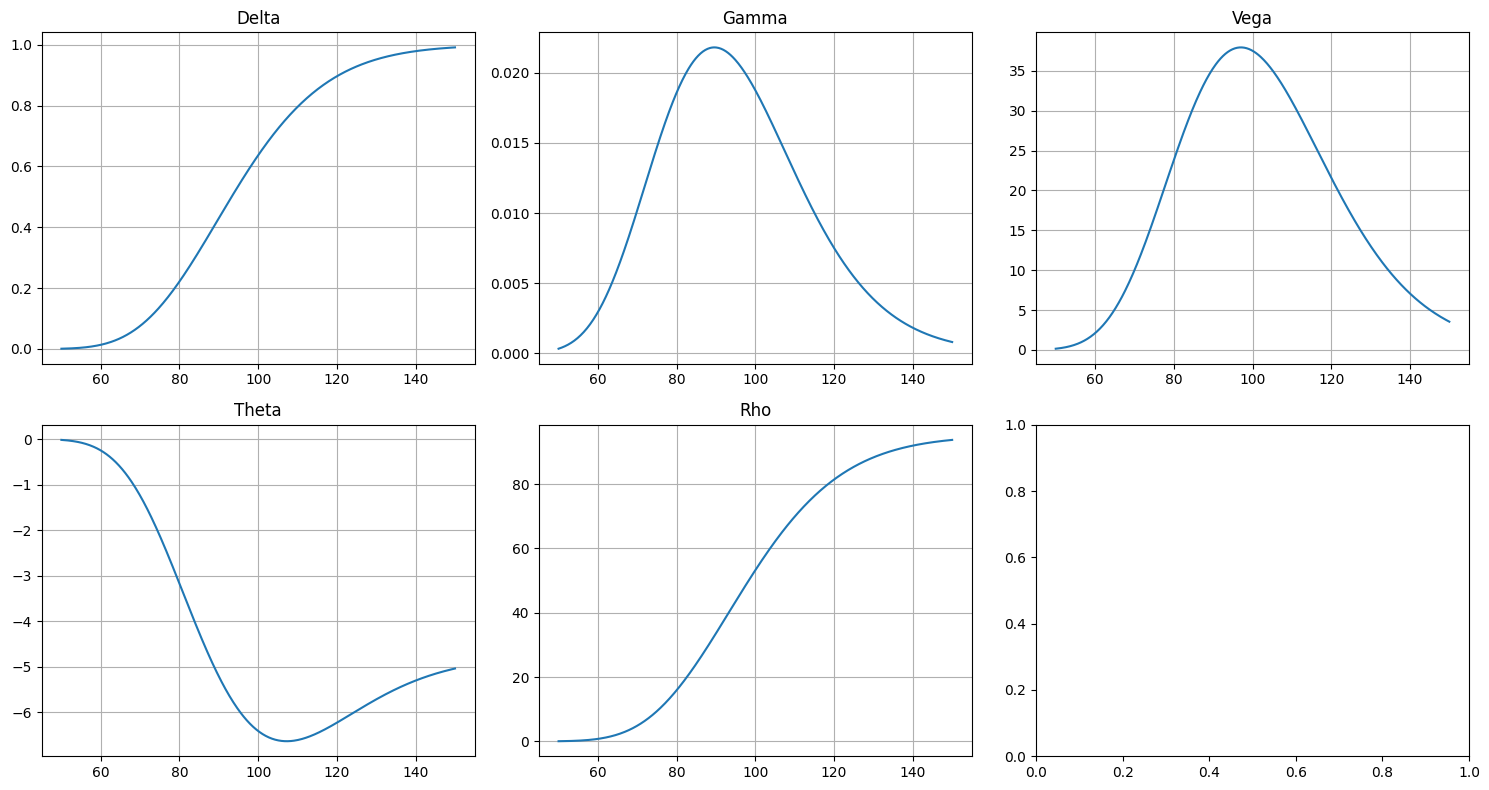

In [20]:
fig, ax = plt.subplots(2,3, figsize=(15,8))

greeks = [
    ('Delta', delta),
    ('Gamma', gamma),
    ('Vega', vega),
    ('Theta', theta),
    ('Rho', rho)
]

for axis, (name, greek) in zip(ax.flatten(), greeks):

    values = [greek(s,T,r,K,sigma) for s in S]

    axis.plot(S, values)
    axis.set_title(name)
    axis.grid()

plt.tight_layout()

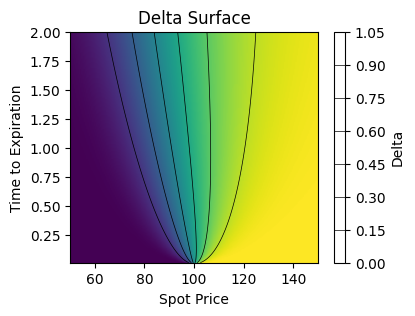

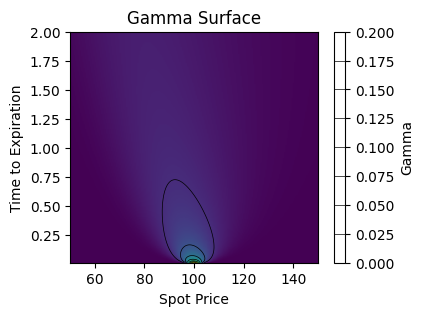

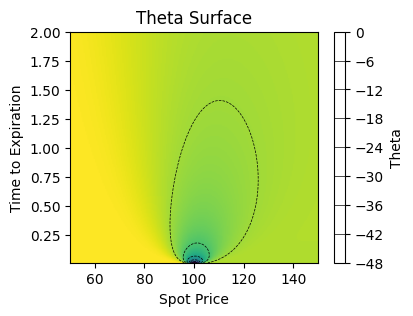

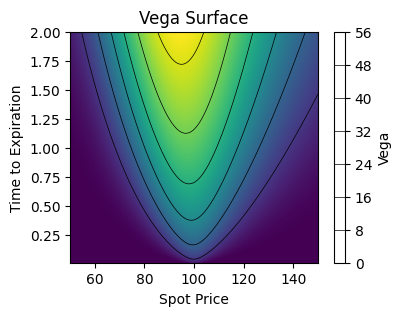

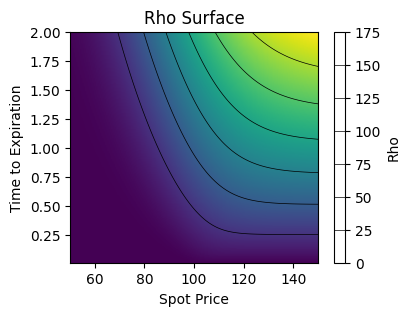

In [28]:
# Heatmap of spot vs time
def spot_time_heatmap(greek:str)-> None:
    
    if greek not in ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho']:
        raise ValueError('Invalid greek')
    
    else:
        greek_functions = {
            'Delta': delta,
            'Gamma': gamma,
            'Theta': theta,
            'Vega': vega,
            'Rho': rho
        }
        S_grid = np.linspace(50,150,200)
        T_grid = np.linspace(0.01,2,200)

        SS, TT = np.meshgrid(S_grid,T_grid)

        target_function = greek_functions[greek]
        vals = target_function(SS, TT, r, K, sigma)

        plt.figure(figsize=(4,3))

        plt.imshow(
            vals,
            origin='lower',
            aspect='auto',
            extent=[
                S_grid.min(),
                S_grid.max(),
                T_grid.min(),
                T_grid.max()
            ]
        )

        plt.contour(
            S_grid,
            T_grid,
            vals,
            colors='black',
            linewidths=0.5
        )
        plt.colorbar(label=greek)
        plt.xlabel('Spot Price')
        plt.ylabel('Time to Expiration')
        plt.title(f'{greek} Surface')

for greek in ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho']:
    spot_time_heatmap(greek)

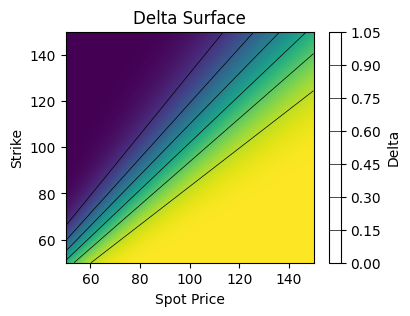

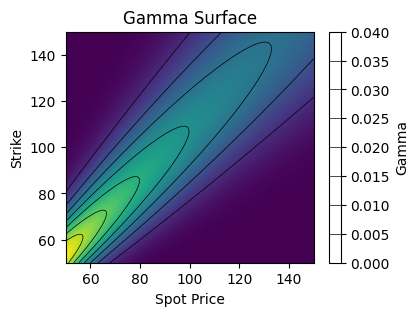

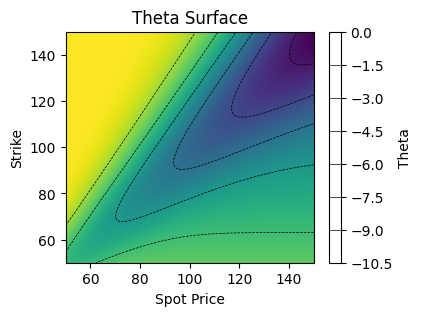

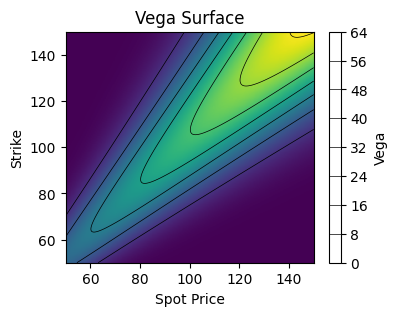

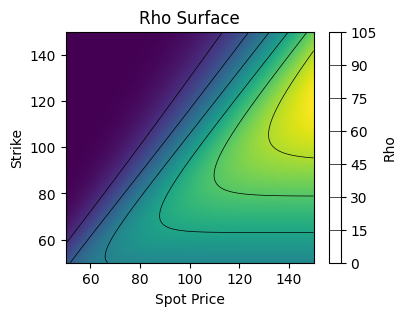

In [29]:
def spot_strike_heatmap(greek:str)->None:
    if greek not in ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho']:
        raise ValueError('Invalid greek')
    
    else:
        greek_functions = {
            'Delta': delta,
            'Gamma': gamma,
            'Theta': theta,
            'Vega': vega,
            'Rho': rho
        }
        S_grid = np.linspace(50,150,200)
        K_grid = np.linspace(50,150,200)

        SS, KK = np.meshgrid(S_grid,K_grid)

        target_function = greek_functions[greek]
        vals = target_function(SS, T, r, KK, sigma)

        plt.figure(figsize=(4,3))

        plt.imshow(
            vals,
            origin='lower',
            aspect='auto',
            extent=[
                S_grid.min(),
                S_grid.max(),
                K_grid.min(),
                K_grid.max()        
            ]
        )
        plt.contour(
            S_grid,
            K_grid,
            vals,
            colors='black',
            linewidths=0.5
        )
        plt.colorbar(label=greek)
        plt.xlabel('Spot Price')
        plt.ylabel('Strike')
        plt.title(f'{greek} Surface')
    
for greek in ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho']:
    spot_strike_heatmap(greek)

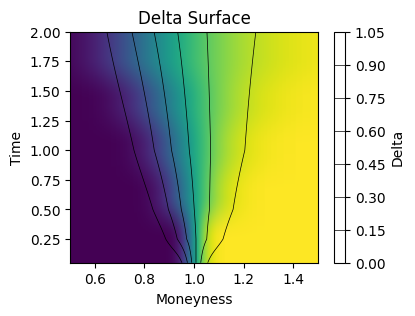

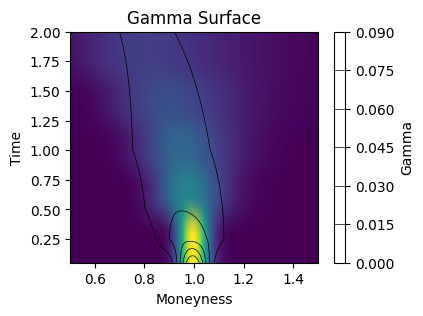

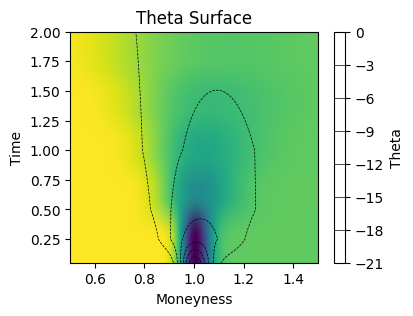

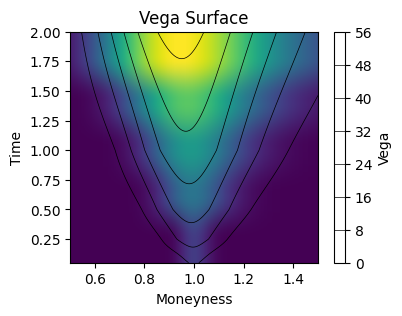

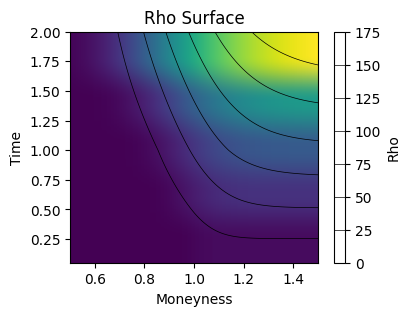

In [34]:
def moneyness_time_heatmap(greek:str)->None:
    if greek not in ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho']:
        raise ValueError('Invalid greek')
    
    else:
        greek_functions = {
            'Delta': delta,
            'Gamma': gamma,
            'Theta': theta,
            'Vega': vega,
            'Rho': rho
        }
        moneyness = np.linspace(0.5,1.5,500)
        S = moneyness*K
        Ts = [0.05,0.25,0.5,1,2]

        SS, TT = np.meshgrid(S, Ts)
        target_function = greek_functions[greek]
        vals = target_function(SS, TT, r, K, sigma)

        plt.figure(figsize=(4,3))

        plt.imshow(
            vals,
            origin='lower',
            aspect='auto',
            extent=[
                moneyness.min(),
                moneyness.max(),
                min(Ts),
                max(Ts)
            ]
        )

        plt.contour(
            moneyness,
            Ts,
            vals,
            colors='black',
            linewidths=0.5
        )
        plt.colorbar(label=greek)
        plt.xlabel('Moneyness')
        plt.ylabel('Time')
        plt.title(f'{greek} Surface')
    
for greek in ['Delta', 'Gamma', 'Theta', 'Vega', 'Rho']:
    moneyness_time_heatmap(greek)